In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

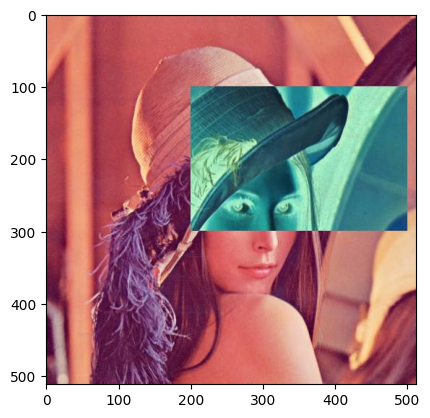

In [3]:
img = cv2.imread("images/result_regions.png.jpeg")

plt.imshow(img[...,::-1])

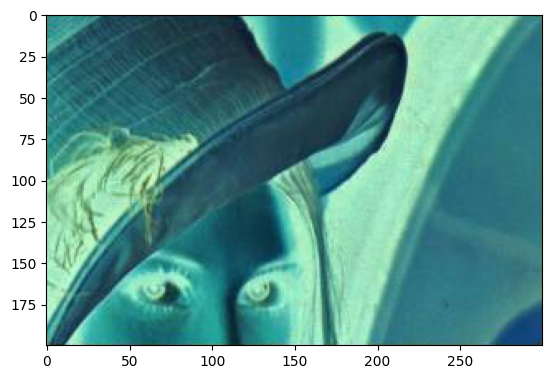

In [60]:
cutted = img[100:300, 200:500]
plt.imshow(cutted[...,::-1])

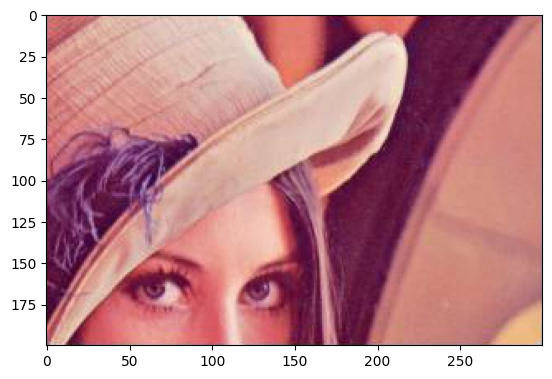

In [61]:
cutted_not = cv2.bitwise_not(cutted)
plt.imshow(cutted_not[...,::-1])

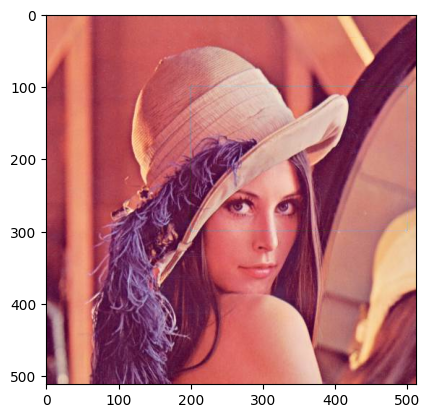

In [64]:
img[100:300, 200:500] = cutted_not
cv2.imwrite("new_lena.jpg", img)
plt.imshow(img[...,::-1])

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

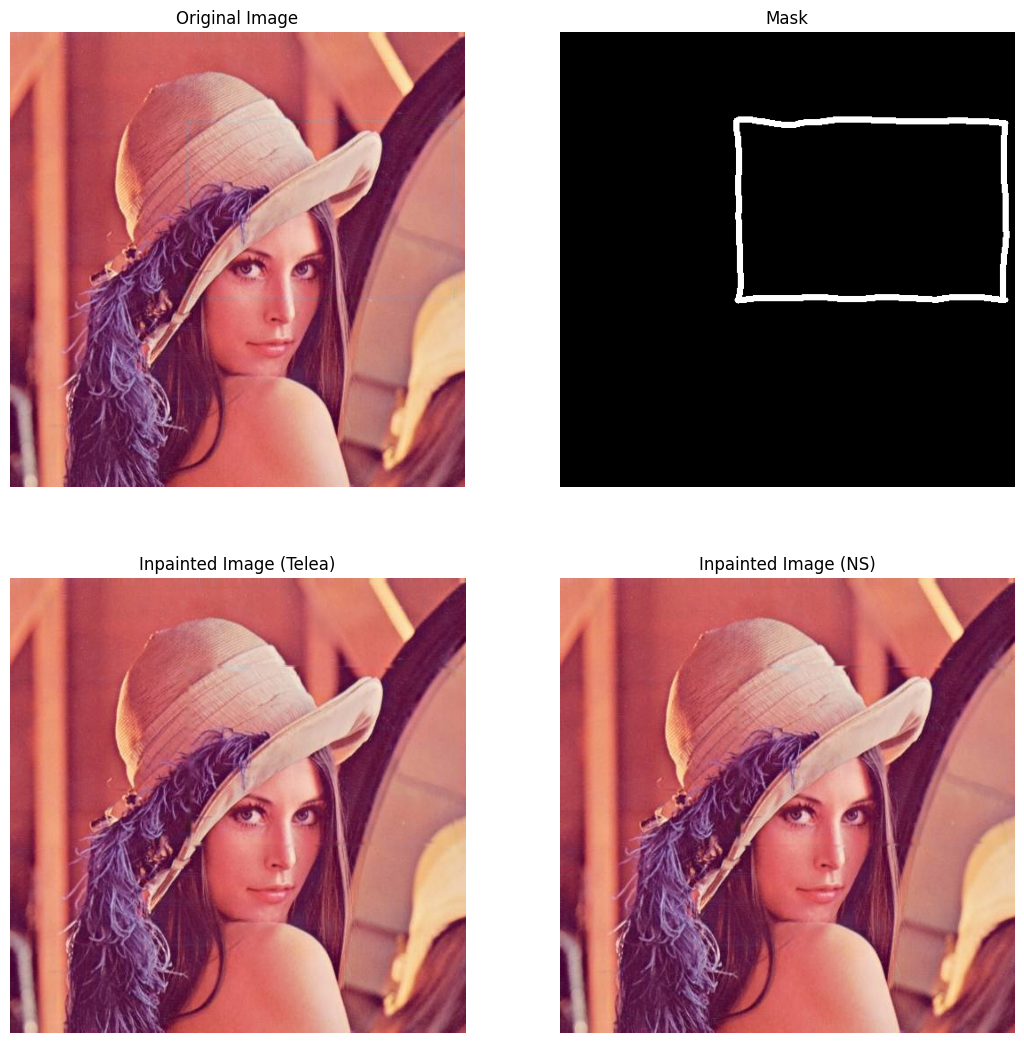

: 

In [ ]:
mask = cv2.imread("inpaintMask.png",0)

res_telea = cv2.inpaint(img, mask,3, cv2.INPAINT_TELEA)
res_ns = cv2.inpaint(img, mask,3, cv2.INPAINT_NS)

plt.figure(figsize=(13,13))
plt.subplot(221);plt.title("Original Image");plt.imshow(img[...,::-1]);plt.axis('off')
plt.subplot(222);plt.title("Mask");plt.imshow(mask, cmap='gray');plt.axis('off')
plt.subplot(223);plt.title("Inpainted Image (Telea)");plt.imshow(res_telea[...,::-1]);plt.axis('off')
plt.subplot(224);plt.title("Inpainted Image (NS)");plt.imshow(res_ns[...,::-1]);plt.axis('off') 

In [65]:
import numpy as np
import cv2 as cv

# OpenCV Utility Class for Mouse Handling
class Sketcher:
    def __init__(self, windowname, dests, colors_func):
        self.prev_pt = None
        self.windowname = windowname
        self.dests = dests
        self.colors_func = colors_func
        self.dirty = False
        self.show()
        cv.setMouseCallback(self.windowname, self.on_mouse)

    def show(self):
        cv.imshow(self.windowname, self.dests[0])
        cv.imshow(self.windowname + ": mask", self.dests[1])

    # onMouse function for Mouse Handling
    def on_mouse(self, event, x, y, flags, param):
        pt = (x, y)
        if event == cv.EVENT_LBUTTONDOWN:
            self.prev_pt = pt
        elif event == cv.EVENT_LBUTTONUP:
            self.prev_pt = None

        if self.prev_pt and flags & cv.EVENT_FLAG_LBUTTON:
            for dst, color in zip(self.dests, self.colors_func()):
                cv.line(dst, self.prev_pt, pt, color, 5)
            self.dirty = True
            self.prev_pt = pt
            self.show()


# Read image in color mode
img = cv.imread("/Users/hadisasadi/Documents/OpenCV/Exercises/new_lena.jpg", cv.IMREAD_COLOR)

# Create a copy of original image
img_mask = img.copy()
# Create a black copy of original image
# Acts as a mask
inpaintMask = np.zeros(img.shape[:2], np.uint8)
# Create sketch using OpenCV Utility Class: Sketcher
sketch = Sketcher('image', [img_mask, inpaintMask], lambda : ((255, 255, 255), 255))

while True:
    ch = cv.waitKey()
    if ch == 27:
        break
    if ch == ord('t'):
        # Use Algorithm proposed by Alexendra Telea: Fast Marching Method (2004)
        # Reference: https://pdfs.semanticscholar.org/622d/5f432e515da69f8f220fb92b17c8426d0427.pdf
        res = cv.inpaint(src=img_mask, inpaintMask=inpaintMask, inpaintRadius=3, flags=cv.INPAINT_TELEA)
        cv.imshow('Inpaint Output using FMM', res)
    if ch == ord('n'):
        # Use Algorithm proposed by Bertalmio, Marcelo, Andrea L. Bertozzi, and Guillermo Sapiro: Navier-Stokes, Fluid Dynamics, and Image and Video Inpainting (2001)
        res = cv.inpaint(src=img_mask, inpaintMask=inpaintMask, inpaintRadius=3, flags=cv.INPAINT_NS)
        cv.imshow('Inpaint Output using NS Technique', res)
    if ch == ord('r'):
        img_mask[:] = img
        inpaintMask[:] = 0
        sketch.show()

print('Completed')
cv.destroyAllWindows()
cv.imwrite("inpaintMask.png",inpaintMask)

Completed


True